# Programming Project 3

# Part 1:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# used the code below to check every row in the data frames given
pd.set_option('display.max_rows', None)

# importing the data files and assigning them to data frames and replacing any missing values '-999' with NaN
rh_data = 'Rh_CN4-molecules.csv'
rh_df = pd.read_csv(rh_data, na_values=['NA', 'N/A', -999], header=1)
co_data = 'Co_CN4-molecules.csv'
co_df = pd.read_csv(co_data, na_values=['NA', 'N/A', -999], header=1)

# takes the mean of each 4 angles and adds them to a new column
rh_df['Mean ANG'] = rh_df.loc[:, 'ANG1':'ANG4'].mean(axis=1)
co_df['Mean ANG'] = co_df.loc[:, 'ANG1':'ANG4'].mean(axis=1)

# to change the position of the Mean ANG column in both data frames
column_names_rh = list(rh_df.columns)
column_names_rh[6], column_names_rh[8] = column_names_rh[8], column_names_rh[6]
column_names_rh[7], column_names_rh[8] = column_names_rh[8], column_names_rh[7]
rh_df = rh_df[column_names_rh]
column_names_co = list(co_df.columns)
column_names_co[6], column_names_co[8] = column_names_co[8], column_names_co[6]
column_names_co[7], column_names_co[8] = column_names_co[8], column_names_co[7]
co_df = co_df[column_names_co]

# to calculate the mean of the 'Mean ANG' column for both data frames
rh_mean_ang_average = rh_df.loc[:, 'Mean ANG'].mean(axis=0)
co_mean_ang_average = co_df.loc[:, 'Mean ANG'].mean(axis=0)

# to calculate the standard deviation of the Mean
rh_standard_dev = rh_df.loc[:, 'Mean ANG'].std()
co_standard_dev = co_df.loc[:, 'Mean ANG'].std()

print('The average mean angle of Rhodium bonds is', round(rh_mean_ang_average, 2),'degrees.')
print('The average mean angle of Cobalt bonds is', round(co_mean_ang_average, 2),'degrees.')
print('The standard deviation of the angles of Rhodium bonds is', round(rh_standard_dev, 2),'.')
print('The standard deviation of the angles of Cobalt bonds is', round(co_standard_dev, 2),'.')


The average mean angle of Rhodium bonds is 90.19 degrees.
The average mean angle of Cobalt bonds is 105.12 degrees.
The standard deviation of the angles of Rhodium bonds is 1.35 .
The standard deviation of the angles of Cobalt bonds is 7.87 .


<b>Comparing values from the data frame to the actual values for the bond angle.</b>

The value that we were given for the <i>Rhodium</i> bonds was <b>90 degrees</b> and for <i>Cobalt</i> it was <b>109.5 degrees</b>. The value I got for the angle between the <i>Rhodium</i> bonds was <b>90.19 degrees</b> and for <i>Cobalt</i> it was <b>105.12 degrees</b>, with standard deviations of <b>1.35</b> and <b>7.87</b> respectively.

The value obtained from the data frames for angle between the <i>Rhodium</i> bonds was close to the given value <b>(0.21% higher)</b>, but the angle for <i>Cobalt</i> was not very close <b>(4% lower)</b>.

The s.d. (standard deviation) of the data for the <i>Rhodium</i> bonds is found to be 1.35 which is a relatively small value compared to the one of the <i>Cobalt's</i>, which is 7.87. This shows that the data for Rhodium was less spread around whereas for Cobalt the data is significantly more spread around.


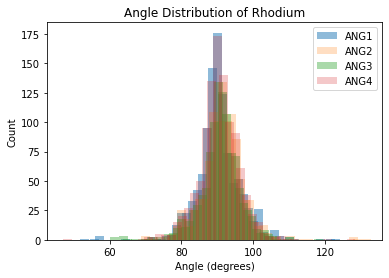

Graph 1: Shows the distribution of bond angles of Rhodium, plotted with the data from the data frame given. The data is not that dispersed and mostly around the mean which is 90.19 degrees.


In [2]:
rh_ang1 = rh_df['ANG1']
rh_ang2 = rh_df['ANG2']
rh_ang3 = rh_df['ANG3']
rh_ang4 = rh_df['ANG4']

plt.hist(rh_ang1, alpha = 0.5, label = 'ANG1', width = 2.5, bins = 50)
plt.hist(rh_ang2, alpha = 0.25, label = 'ANG2', width = 2.5, bins = 50)
plt.hist(rh_ang3, alpha = 0.4, label = 'ANG3', width = 2.5, bins = 50)
plt.hist(rh_ang4, alpha = 0.25, label = 'ANG4', width = 2.5, bins = 50)
plt.xlabel('Angle (degrees)')
plt.ylabel('Count')
plt.title('Angle Distribution of Rhodium')
plt.legend()
plt.show()

print('Graph 1: Shows the distribution of bond angles of Rhodium, plotted with the data from the data frame given. The data is not that dispersed and mostly around the mean which is 90.19 degrees.')

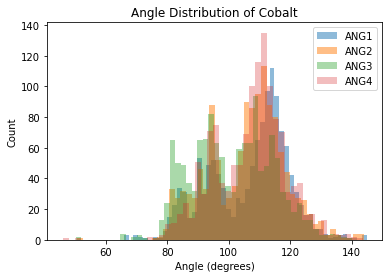

Graph 2: Shows the distribution of bond angle of Cobalt, plotted with teh data from the data frame given. The data is quite despersed and it does not show a clear mean.


In [3]:
co_ang1 = co_df['ANG1']
co_ang2 = co_df['ANG2']
co_ang3 = co_df['ANG3']
co_ang4 = co_df['ANG4']

plt.hist(co_ang1, alpha = 0.5, label = 'ANG1', bins = 50)
plt.hist(co_ang2, alpha = 0.5, label = 'ANG2', bins = 50)
plt.hist(co_ang3, alpha = 0.4, label = 'ANG3', bins = 50)
plt.hist(co_ang4, alpha = 0.3, label = 'ANG4', bins = 50)
plt.xlabel('Angle (degrees)')
plt.ylabel('Count')
plt.title('Angle Distribution of Cobalt')
plt.legend()
plt.show()

print('Graph 2: Shows the distribution of bond angle of Cobalt, plotted with teh data from the data frame given. The data is quite despersed and it does not show a clear mean.')

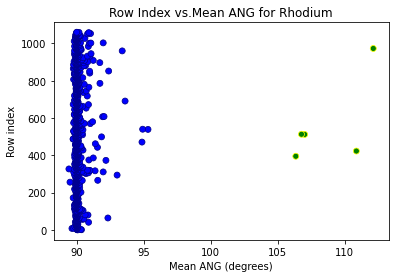

Graph 3: Shows the distribution of bond angle of Rhodium, plotted with the data from the data frame given. With this plot it is easier to spot the anomalies in the data frame which are the green data points.


In [4]:
# conditions for color and edgecolor of data points 
colors1 = []
edgecolors1 = []
for x in rh_df['Mean ANG']:
    if x < 105:
        colors1.append('blue')
    else:
        colors1.append('green')

edgecolors = []
for x in rh_df['Mean ANG']:
    if x < 105:
        edgecolors1.append('darkblue')
    else:
        edgecolors1.append('yellow')

plt.scatter(rh_df['Mean ANG'], rh_df.index, color=colors1, edgecolors=edgecolors1, linewidths = 0.75)

#labels 
plt.xlabel('Mean ANG (degrees)')
plt.ylabel('Row index')
plt.title('Row Index vs.Mean ANG for Rhodium')
plt.show()

print('Graph 3: Shows the distribution of bond angle of Rhodium, plotted with the data from the data frame given. With this plot it is easier to spot the anomalies in the data frame which are the green data points.')

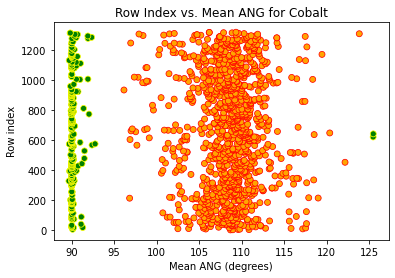

Graph 4: Shows the distribution of bond angle of Rhodium, plotted with the data from the data frame given. With this plot it is easier to spot the anomalies in the data frame which are the green data points, which there is a lot of.


In [5]:
# conditions for color and edgecolor of data points 
colors2 = []
edgecolors2 = []
for x in co_df['Mean ANG']:
    if x < 95:
        colors2.append('green')
    elif x > 125:
        colors2.append('green')
    else:
        colors2.append('orange')

edgecolors = []
for x in co_df['Mean ANG']:
    if x < 95:
        edgecolors2.append('yellow')
    elif x > 125:
        edgecolors2.append('yellow')
    else:
        edgecolors2.append('red')

plt.scatter(co_df['Mean ANG'], co_df.index, color=colors2, edgecolors=edgecolors2, linewidths=0.75)

# labels
plt.xlabel('Mean ANG (degrees)')
plt.ylabel('Row index')
plt.title('Row Index vs. Mean ANG for Cobalt')

plt.show()

print('Graph 4: Shows the distribution of bond angle of Rhodium, plotted with the data from the data frame given. With this plot it is easier to spot the anomalies in the data frame which are the green data points, which there is a lot of.')

<b>Graphs above (1-4) show the distribution of angles of Rhodium and Cobalt molecules according to the data frame.

# Part 2

In [6]:
# to estimate if the molecule is planar or tetrahedral shape

planar_angle = 90 # (degrees)
tetrahedral_angle = 109.5 # (degrees)

rh1 = rh_df.loc[rh_df['Refcode'] == 'YIQQUK']
co1 = co_df.loc[co_df['Refcode'] == 'ZOJPUJ01']
co2 = co_df.loc[co_df['Refcode'] == 'ICAYES']
co3 = co_df.loc[co_df['Refcode'] == 'ZABVIK']
rh1_mean = rh1['Mean ANG'].values[0]
co1_mean = co1['Mean ANG'].values[0]
co2_mean = co2['Mean ANG'].values[0]
co3_mean = co3['Mean ANG'].values[0]


# calculating the percentage off from planar and tetrahedral shapes
rh_planar_off = abs(round(((planar_angle-rh1_mean)/planar_angle)*100, 3))
rh_tetra_off = abs(round(((tetrahedral_angle-rh1_mean)/tetrahedral_angle)*100, 3))
co1_planar_off = abs(round(((planar_angle-co1_mean)/planar_angle)*100, 3))
co1_tetra_off = abs(round(((tetrahedral_angle-co1_mean)/tetrahedral_angle)*100, 3))
co2_planar_off = abs(round(((planar_angle-co2_mean)/planar_angle)*100, 3))
co2_tetra_off = abs(round(((tetrahedral_angle-co2_mean)/tetrahedral_angle)*100, 3))
co3_planar_off = abs(round(((planar_angle-co3_mean)/planar_angle)*100, 3))
co3_tetra_off = abs(round(((tetrahedral_angle-co3_mean)/tetrahedral_angle)*100, 3))

rh_type = str()
co1_type = str()
co2_type = str()
co3_type = str()

# to see which shape the molecule is closer to
if rh_planar_off < rh_tetra_off:
    rh_type = str('Planar')
else:
    rh_type = str('Tetrahedral')

if co1_planar_off<co1_tetra_off:
    co1_type = str('Planar')
else:
    co1_type = str('Tetrahedral')

if co2_planar_off<co2_tetra_off:
    co2_type = str('Planar')
else:
    co2_type = str('Tetrahedral')

if co3_planar_off<co3_tetra_off:
    co3_type = str('Planar')
else:
    co3_type = str('Tetrahedral')

print('The Rhodium moleucle with the Refcode YIQQUK is more likely to have a', rh_type, 'shape, because it is', rh_planar_off, '% less than the planar angle (90 degrees) and', rh_tetra_off,'% less than the tetrahedral angle (109.5 degrees).')
print('The Cobalt moleucle with the Refcode ZOJPUJ01 is more likely to have a', co1_type, 'shape, because it is', co1_planar_off, '% less than the planar angle (90 degrees) and', co1_tetra_off,'% less than the tetrahedral angle (109.5 degrees).')
print('The Cobalt moleucle with the Refcode ICAYES is more likely to have a', co2_type, 'shape, because it is', co2_planar_off, '% less than the planar angle (90 degrees) and', co2_tetra_off,'% less than the tetrahedral angle (109.5 degrees).')
print('The Cobalt moleucle with the Refcode ZABVIK is more likely to have a', co3_type, 'shape, because it is', co3_planar_off, '% less than the planar angle (90 degrees) and', co3_tetra_off,'% less than the tetrahedral angle (109.5 degrees).')

The Rhodium moleucle with the Refcode YIQQUK is more likely to have a Planar shape, because it is 0.005 % less than the planar angle (90 degrees) and 17.813 % less than the tetrahedral angle (109.5 degrees).
The Cobalt moleucle with the Refcode ZOJPUJ01 is more likely to have a Tetrahedral shape, because it is 13.402 % less than the planar angle (90 degrees) and 6.793 % less than the tetrahedral angle (109.5 degrees).
The Cobalt moleucle with the Refcode ICAYES is more likely to have a Tetrahedral shape, because it is 23.439 % less than the planar angle (90 degrees) and 1.457 % less than the tetrahedral angle (109.5 degrees).
The Cobalt moleucle with the Refcode ZABVIK is more likely to have a Planar shape, because it is 0.024 % less than the planar angle (90 degrees) and 17.788 % less than the tetrahedral angle (109.5 degrees).


<b>The code above (In [9]) calculates how far off the Mean ANG values for each data set are (in certain rows defined by the Refcode) from the agnles for Planar and Tetrahedral shapes and then prints out a statement.

In [7]:
# deciding whether the molecule has a planar or tetrahedral shape for each data frame
rh_diffplanar = abs(90 - rh_df['Mean ANG'])
rh_difftetra = abs(109.5 - rh_df['Mean ANG'])
co_diffplanar = abs(90 - co_df['Mean ANG'])
co_difftetra = abs(109.5 - co_df['Mean ANG'])

# inserting a column named 'Molecule Shape' depending on the conditions
rh_df['Molecule Shape'] = np.where(rh_diffplanar < rh_difftetra, 'Planar', 'Tetrahedral')
co_df['Molecule Shape'] = np.where(co_diffplanar < co_difftetra, 'Planar', 'Tetrahedral')


rh2 = rh_df.loc[rh_df['Refcode'] == 'YIQQUK']
co4 = co_df.loc[co_df['Refcode'] == 'ZOJPUJ01']
co5 = co_df.loc[co_df['Refcode'] == 'ICAYES']
co6 = co_df.loc[co_df['Refcode'] == 'ZABVIK']

# checking if the predictions match the data
if rh_type == rh2['Molecule Shape'].values[0]:
    print('The prediction for the shape of the Rhodium moleucle with the Refcode YIQQUK matches the data.')
else:
    print('The prediction for the shape of the Rhodium moleucle with the Refcode YIQQUK does not matche the data.')

if co1_type == co4['Molecule Shape'].values[0]:
    print('The prediction for the shape of the Cobalt moleucle with the Refcode ZOJPUJ01 matches the data.')
else:
    print('The prediction for the shape of the Cobalt moleucle with the Refcode ZOJPUJ01 does not matche the data.')

if co2_type == co5['Molecule Shape'].values[0]:
    print('The prediction for the shape of the Cobalt moleucle with the Refcode ICAYES matches the data.')
else:
    print('The prediction for the shape of the Cobalt moleucle with the Refcode ICAYES does not matche the data.')

if co3_type == co6['Molecule Shape'].values[0]:
    print('The prediction for the shape of the Cobalt moleucle with the Refcode ZABVIK matches the data.')
else:
    print('The prediction for the shape of the Cobalt moleucle with the Refcode ZABVIK does not matche the data.')


The prediction for the shape of the Rhodium moleucle with the Refcode YIQQUK matches the data.
The prediction for the shape of the Cobalt moleucle with the Refcode ZOJPUJ01 matches the data.
The prediction for the shape of the Cobalt moleucle with the Refcode ICAYES matches the data.
The prediction for the shape of the Cobalt moleucle with the Refcode ZABVIK matches the data.


<b>The code above (In [10]) does part2.2 of the project.